# Comparison -- all strategies so far (Levers 1-3), side by side

Self-contained (own data load, own formulas -- nothing imported from `deprecated/` or any
other notebook).

Runs every arm tested across Levers 1-3 on the same three windows (train, Test A
decline, Test B rally), using the same frozen moneyness/DTE/roll from Lever 2
(20% OTM, 180-DTE target, 7-day roll trigger):

- `tsla_only` -- always TSLA calls (Lever 1 baseline)
- `tsll_only` -- always TSLL calls (Lever 1 baseline)
- `cost_benefit` -- price both, buy cheaper, no coverage-band correction (Lever 1's
  rule; also Lever 2's winner exactly, since Lever 2 always used `cost_benefit`)
- `cost_benefit + band_tight` (10%) -- Lever 3's winner
- `cost_benefit + band_medium` (25%) -- Lever 3 arm, did not survive the held-out gate
- `cost_benefit + band_loose` (50%) -- Lever 3 arm, did not survive the held-out gate

Windows and how they were picked: **train** = 2022-09-09 -> 2023-01-03 (the first TSLA/
TSLL crash, trimmed to start after `ESTIMATION_WINDOW=21`'s first genuine trailing
window). **Test A** = 2024-12-17 -> 2025-04-08, a real historical decline (TSLL
$40.09 -> $6.79). **Test B** = 2025-04-08 -> 2025-12-16, a real historical rally
immediately following Test A (TSLL $6.79 -> $23.03). All three windows were fixed before
any lever was tested, using genuine historical episodes covering both directions, not
chosen or adjusted after seeing results.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]
DATA = ROOT / "data"
%matplotlib inline

## Load data (fresh parse, same conventions as `00_foundation_sandbox.ipynb`)

In [2]:
tsla_raw = pd.read_excel(DATA / "Excel3_Underlying_Data.xlsx", sheet_name="TSLA", header=10)
tsla_raw["Date"] = pd.to_datetime(tsla_raw["Date"])
tsla_spot = tsla_raw.set_index("Date")["Close"].sort_index().dropna()

tsll_raw = pd.read_excel(DATA / "TSLL_ohlcv.xlsx", sheet_name="TSLL")
tsll_raw["Date"] = pd.to_datetime(tsll_raw["Date"])
tsll_spot = tsll_raw.set_index("Date")["Close"].sort_index().dropna()

tsla_calls = pd.read_parquet(DATA / "processed" / "TSLA_calls_close.parquet")
tsll_calls = pd.read_parquet(DATA / "processed" / "TSLL_calls_close.parquet")

r_tsla = tsla_spot.pct_change().dropna()
r_tsll = tsll_spot.pct_change().dropna()
dates = r_tsla.index.intersection(r_tsll.index)
r_tsla, r_tsll = r_tsla.loc[dates], r_tsll.loc[dates]
tsla_spot, tsll_spot = tsla_spot.loc[dates], tsll_spot.loc[dates]

print(f"{len(dates):,} trading days, {dates.min().date()} -> {dates.max().date()}")

960 trading days, 2022-08-10 -> 2026-06-08


## Pre-indexed lookups (performance only)

In [3]:
tsla_calls_by_date = {d: g for d, g in tsla_calls.groupby("date")}
tsll_calls_by_date = {d: g for d, g in tsll_calls.groupby("date")}

tsla_price_lookup = {(r.raw_id, r.date): r.px_last for r in tsla_calls.itertuples(index=False)}
tsll_price_lookup = {(r.raw_id, r.date): r.px_last for r in tsll_calls.itertuples(index=False)}

## Fresh formulas -- Black-Scholes delta, rolling vol/beta, contract selection, sizing, risk metrics

In [4]:
R_RF = 0.05              # stated assumption, not estimated (per project scope)
ESTIMATION_WINDOW = 21   # stated convention (~1 trading month), not tested/optimized

MONEYNESS_RANGES = {
    "ATM": (0.95, 1.05),
    "10% OTM": (1.05, 1.15),
    "20% OTM": (1.15, 1.25),
}


def bs_call_delta(S, K, T_years, r, sigma):
    """Black-Scholes European call delta = N(d1). Clipped to [0.01, 1.0]."""
    if T_years <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 1.0 if S > K else 0.01
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T_years) / (sigma * np.sqrt(T_years))
    return float(np.clip(norm.cdf(d1), 0.01, 1.0))


tsla_sigma = (r_tsla.rolling(ESTIMATION_WINDOW).std() * np.sqrt(252)).ffill().bfill()
tsll_sigma = (r_tsll.rolling(ESTIMATION_WINDOW).std() * np.sqrt(252)).ffill().bfill()
beta_tsll_vs_tsla = ((r_tsll.rolling(ESTIMATION_WINDOW).cov(r_tsla)
                      / r_tsla.rolling(ESTIMATION_WINDOW).var()).shift(1)).ffill().bfill()

assert tsla_sigma.isna().sum() == 0 and tsll_sigma.isna().sum() == 0 and beta_tsll_vs_tsla.isna().sum() == 0


def select_contract(calls_by_date, spot_series, date, moneyness_bucket, target_dte, max_dte):
    """Filter to the moneyness bucket, require a real fill, positive DTE within max_dte,
    pick the contract closest to target_dte. Moneyness is ALWAYS bounded."""
    day = calls_by_date.get(date)
    if day is None or day.empty:
        return None
    lo, hi = MONEYNESS_RANGES[moneyness_bucket]
    s = float(spot_series.loc[date])
    moneyness = day["strike"] / s
    dte = (day["expiry"] - date).dt.days
    mask = (
        (moneyness >= lo) & (moneyness < hi)
        & (dte > 0) & (dte <= max_dte)
        & day["px_last"].notna() & (day["px_last"] > 0)
        & day["px_volume"].notna() & (day["px_volume"] > 0)
    )
    candidates = day[mask]
    if candidates.empty:
        return None
    dte_c = (candidates["expiry"] - date).dt.days
    idx = (dte_c - target_dte).abs().idxmin()
    return candidates.loc[idx]


def size_position(row, spot_val, sigma_val, target_dollar_delta, date):
    """Delta-neutral contract count for a given target dollar-delta. CONTRACTS, not
    shares -- cost is always n_contracts * 100 * entry_price."""
    if row is None:
        return 0.0, float("inf"), 0.0
    entry = float(row["px_last"])
    T = max((row["expiry"] - date).days / 365.25, 1 / 365)
    delta = bs_call_delta(float(spot_val), float(row["strike"]), T, R_RF, sigma_val)
    n_contracts = target_dollar_delta / (max(delta, 0.01) * 100 * spot_val)
    cost = n_contracts * 100 * entry
    return n_contracts, cost, entry


def cagr(equity):
    n_years = (equity.index[-1] - equity.index[0]).days / 365.25
    end = equity.iloc[-1]
    return -1.0 if end <= 0 else end ** (1 / n_years) - 1


def sharpe(returns, rf=0.0):
    excess = returns - rf / 252
    vol = excess.std()
    return float("nan") if vol == 0 else excess.mean() / vol * np.sqrt(252)


def max_drawdown(equity):
    return (equity / equity.cummax() - 1).min()

## Simulation -- combines Lever 1's instrument-choice toggle and Lever 3's coverage-band toggle

In [5]:
def simulate(sim_dates, instrument_rule, band_width, moneyness_bucket, target_dte, roll_dte, max_dte, notional=1.0):
    """instrument_rule in {"tsla_only", "tsll_only", "cost_benefit"}.
    band_width=None disables the coverage-band check; a float enables an unconditional
    resize whenever coverage drifts outside [1-band_width, 1+band_width]."""
    S_incep = float(tsll_spot.loc[sim_dates[0]])
    n_shares = notional / S_incep

    short_pnl = 0.0
    option_pnl = 0.0
    position = None
    S_prev = S_incep

    equity = pd.Series(index=sim_dates, dtype=float)

    def mtm(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        lookup = tsla_price_lookup if pos["underlying"] == "tsla" else tsll_price_lookup
        if date > pos["expiry"]:
            return max(float(spot_series.loc[date]) - pos["strike"], 0.0)
        px = lookup.get((pos["raw_id"], date))
        if px is None or pd.isna(px):
            return pos["price"]
        return float(px)

    def current_delta(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        sigma_series = tsla_sigma if pos["underlying"] == "tsla" else tsll_sigma
        S_pos = float(spot_series.loc[date])
        T = max((pos["expiry"] - date).days / 365.25, 1 / 365)
        return bs_call_delta(S_pos, pos["strike"], T, R_RF, float(sigma_series.loc[date])), S_pos

    for d in sim_dates:
        S_today = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today

        if position is not None:
            px = mtm(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        current_short_dd = n_shares * S_today

        held_dte = (position["expiry"] - d).days if position is not None else -1
        forced_roll = position is None or held_dte < roll_dte

        band_triggered = False
        if position is not None and band_width is not None and not forced_roll:
            delta_now, S_pos_now = current_delta(position, d)
            current_hedge_dd = position["n"] * 100 * delta_now * S_pos_now
            coverage_ratio = current_hedge_dd / current_short_dd if current_short_dd > 0 else 1.0
            if coverage_ratio < (1 - band_width) or coverage_ratio > (1 + band_width):
                band_triggered = True

        need_roll = forced_roll or band_triggered

        if need_roll:
            beta_t = float(beta_tsll_vs_tsla.loc[d])
            if forced_roll:
                target_dollar_delta_tsla = beta_t * notional
                target_dollar_delta_tsll = notional
            else:
                target_dollar_delta_tsla = beta_t * current_short_dd
                target_dollar_delta_tsll = current_short_dd

            sig_tsla = float(tsla_sigma.loc[d])
            sig_tsll = float(tsll_sigma.loc[d])

            row_tsla = select_contract(tsla_calls_by_date, tsla_spot, d, moneyness_bucket, target_dte, max_dte)
            row_tsll = select_contract(tsll_calls_by_date, tsll_spot, d, moneyness_bucket, target_dte, max_dte)
            n_a, cost_a, entry_a = size_position(row_tsla, float(tsla_spot.loc[d]), sig_tsla, target_dollar_delta_tsla, d)
            n_b, cost_b, entry_b = size_position(row_tsll, float(tsll_spot.loc[d]), sig_tsll, target_dollar_delta_tsll, d)

            chosen = None
            if instrument_rule == "tsla_only" and row_tsla is not None:
                chosen = "tsla"
            elif instrument_rule == "tsll_only" and row_tsll is not None:
                chosen = "tsll"
            elif instrument_rule == "cost_benefit":
                if row_tsla is not None and (row_tsll is None or cost_a <= cost_b):
                    chosen = "tsla"
                elif row_tsll is not None:
                    chosen = "tsll"

            if chosen == "tsla":
                position = {"underlying": "tsla", "raw_id": row_tsla["raw_id"], "strike": float(row_tsla["strike"]),
                            "expiry": row_tsla["expiry"], "n": n_a, "price": entry_a}
            elif chosen == "tsll":
                position = {"underlying": "tsll", "raw_id": row_tsll["raw_id"], "strike": float(row_tsll["strike"]),
                            "expiry": row_tsll["expiry"], "n": n_b, "price": entry_b}
            else:
                position = None

        equity.loc[d] = notional + short_pnl + option_pnl

    return equity

## Windows + frozen Lever 2 config

In [6]:
TRAIN_START = pd.Timestamp("2022-09-09")
TRAIN_END = pd.Timestamp("2023-01-03")
TEST_A_START = pd.Timestamp("2024-12-17")   # decline
TEST_A_END = pd.Timestamp("2025-04-08")
TEST_B_START = pd.Timestamp("2025-04-08")   # rally
TEST_B_END = pd.Timestamp("2025-12-16")

train_dates = dates[(dates >= TRAIN_START) & (dates <= TRAIN_END)]
test_a_dates = dates[(dates >= TEST_A_START) & (dates <= TEST_A_END)]
test_b_dates = dates[(dates >= TEST_B_START) & (dates <= TEST_B_END)]
WINDOWS = {"train": train_dates, "testA": test_a_dates, "testB": test_b_dates}

MONEYNESS_BUCKET = "20% OTM"
TARGET_DTE = 180
ROLL_DTE = 7
MAX_DTE = TARGET_DTE + 20

print(f"Train:  {len(train_dates)} days, {train_dates.min().date()} -> {train_dates.max().date()}")
print(f"Test A: {len(test_a_dates)} days, {test_a_dates.min().date()} -> {test_a_dates.max().date()} (decline)")
print(f"Test B: {len(test_b_dates)} days, {test_b_dates.min().date()} -> {test_b_dates.max().date()} (rally)")

Train:  80 days, 2022-09-09 -> 2023-01-03
Test A: 76 days, 2024-12-17 -> 2025-04-08 (decline)
Test B: 175 days, 2025-04-08 -> 2025-12-16 (rally)


## Every arm tested across Levers 1-3, run on all three windows

In [7]:
ARMS = {
    "tsla_only":            dict(instrument_rule="tsla_only",    band_width=None),
    "tsll_only":             dict(instrument_rule="tsll_only",    band_width=None),
    "cost_benefit":          dict(instrument_rule="cost_benefit", band_width=None),
    "cost_benefit+tight":    dict(instrument_rule="cost_benefit", band_width=0.10),
    "cost_benefit+medium":   dict(instrument_rule="cost_benefit", band_width=0.25),
    "cost_benefit+loose":    dict(instrument_rule="cost_benefit", band_width=0.50),
}

rows = []
curves = {}
for arm_name, params in ARMS.items():
    for win_name, win_dates in WINDOWS.items():
        eq = simulate(win_dates, params["instrument_rule"], params["band_width"],
                      MONEYNESS_BUCKET, TARGET_DTE, ROLL_DTE, MAX_DTE)
        curves[(arm_name, win_name)] = eq
        rows.append({
            "arm": arm_name, "window": win_name,
            "sharpe": sharpe(eq.pct_change().dropna()),
            "cagr": cagr(eq),
            "maxdd": max_drawdown(eq),
        })

comparison = pd.DataFrame(rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

## Comparison table -- one row per arm per window

In [8]:
pivot = comparison.pivot(index="arm", columns="window", values=["sharpe", "cagr", "maxdd"])
pivot = pivot.reindex(list(ARMS.keys()))
pivot

sharpe                          cagr                         maxdd                    
window                  testA     testB     train     testA     testB     train     testA     testB     train
arm                                                                                                          
tsla_only            1.483990  0.751063  2.729958  0.717196 -0.026452  1.669685 -0.190838 -0.439411 -0.088150
tsll_only            2.307947  1.311541  1.741592  1.466017 -1.000000  1.211122 -0.164489 -1.804917 -0.135081
cost_benefit         1.483990  0.664628  2.036744  0.717196 -0.165135  1.477564 -0.190838 -0.489381 -0.149891
cost_benefit+tight   1.743815  0.825312  1.553370  0.904336  0.446272  0.640394 -0.111373 -0.359053 -0.089611
cost_benefit+medium  0.997483 -0.327637  0.394296  0.340727 -0.924357  0.078928 -0.118623 -0.833418 -0.147868
cost_benefit+loose   1.685764 -2.050505  1.546394  0.750304 -1.000000  0.857699 -0.115767 -1.345993 -0.149891

## Equity curves, one panel per window, all arms overlaid

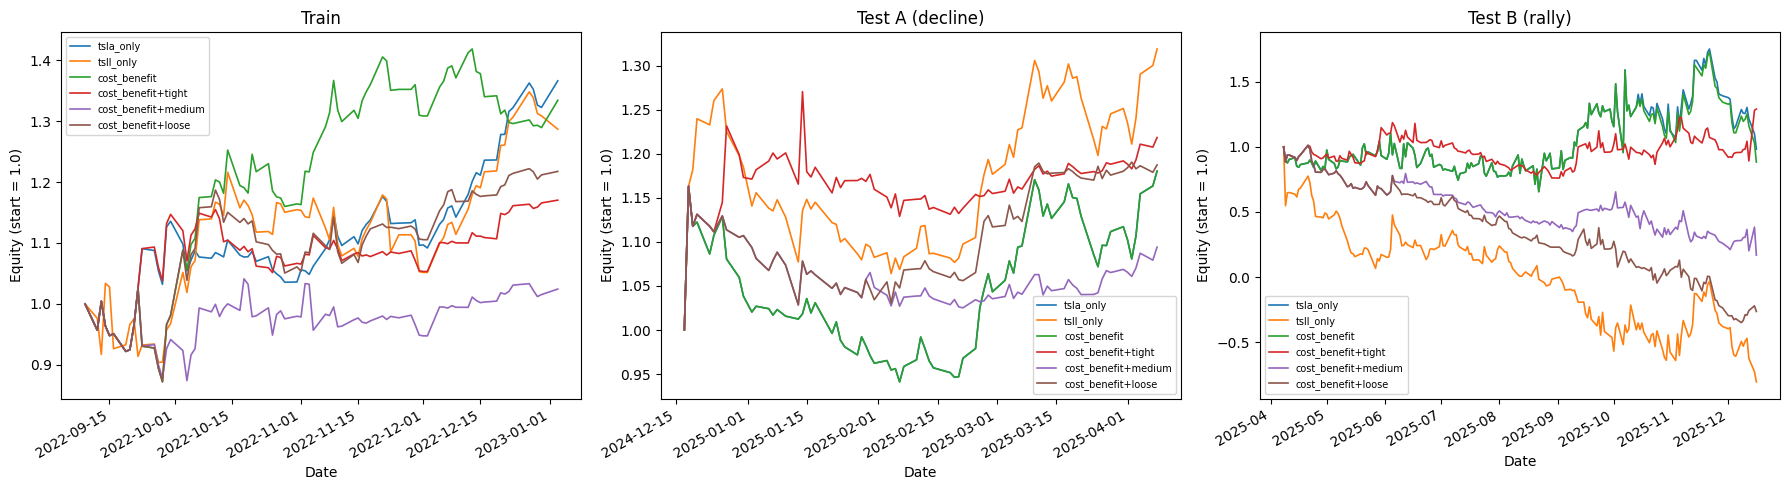

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, win_name, title in zip(axes, ["train", "testA", "testB"], ["Train", "Test A (decline)", "Test B (rally)"]):
    for arm_name in ARMS:
        curves[(arm_name, win_name)].plot(ax=ax, label=arm_name, linewidth=1.2)
    ax.set_title(title)
    ax.set_ylabel("Equity (start = 1.0)")
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

## Sanity checks

In [10]:
for (arm_name, win_name), eq in curves.items():
    assert eq.isna().sum() == 0, f"{arm_name}/{win_name}: equity has NaNs"
assert len(comparison) == len(ARMS) * len(WINDOWS)

# consistency: cost_benefit with no band must match Lever 2's winner; cost_benefit+tight must match Lever 3's winner
cb_testB = pivot.loc["cost_benefit", ("maxdd", "testB")]
tight_testB = pivot.loc["cost_benefit+tight", ("maxdd", "testB")]
assert abs(cb_testB - (-0.489381)) < 0.01, "cost_benefit (no band) doesn't match Lever 2's winner"
assert abs(tight_testB - (-0.359053)) < 0.01, "cost_benefit+tight doesn't match Lever 3's winner"

print("Comparison sanity checks passed -- consistent with Lever 2 and Lever 3's standalone results.")

Comparison sanity checks passed -- consistent with Lever 2 and Lever 3's standalone results.
